# 06 — Best CNN (Final)
Self-contained final CNN training/evaluation notebook. Selected tuning config: LR=0.001, dropout=0.30, batch=32.

In [ ]:
!pip -q install soundfile librosa scikit-learn pandas matplotlib

import os, random, warnings
from pathlib import Path
import numpy as np, pandas as pd, soundfile as sf, librosa
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
warnings.filterwarnings("ignore")

SEED=42; SR=22050; DURATION=2.0; N_MELS=64; N_FFT=512; HOP_LENGTH=256
BATCH_SIZE=32; LEARNING_RATE=1e-3; DROPOUT=0.30; EPOCHS=30
AUDIO_ROOT=Path("/content/gtzan"); MANIFEST=Path("/content/split_manifest.csv")
CHECKPOINT=Path("/content/best_cnn.pt")
HISTORY_CSV=Path("/content/final_cnn_history.csv")
METRICS_CSV=Path("/content/best_cnn_metrics.csv")
REPORT_CSV=Path("/content/best_cnn_classification_report.csv")
CONFUSION_CSV=Path("/content/best_cnn_confusion_matrix.csv")
CONFUSION_PNG=Path("/content/best_cnn_confusion_matrix.png")
GENRES=["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]
G2I={g:i for i,g in enumerate(GENRES)}
DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_all(s=42):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)
seed_all(SEED)

print("Device:", DEVICE)
if torch.cuda.is_available(): print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
GPU: Tesla T4


In [2]:
# ============================================================
# FINAL CNN - DATA SETUP + PATH FIX
# REPLACE THE OLD FAILING CELL WITH THIS ENTIRE CELL
# ============================================================

from pathlib import Path
import pandas as pd
import os
import shutil

# ------------------------------------------------------------
# 1. LOCATIONS
# ------------------------------------------------------------

AUDIO_ROOT = Path("/content/gtzan")
MANIFEST = Path("/content/split_manifest.csv")

GENRES = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

# ------------------------------------------------------------
# 2. GET MANIFEST
# ------------------------------------------------------------

if not MANIFEST.exists():

    from google.colab import files

    print("Upload split_manifest.csv")
    uploaded = files.upload()

    if "split_manifest.csv" in uploaded:
        MANIFEST = Path("/content/split_manifest.csv")
    else:
        csv_files = [
            x for x in uploaded.keys()
            if x.lower().endswith(".csv")
        ]

        if not csv_files:
            raise FileNotFoundError(
                "No CSV file was uploaded."
            )

        MANIFEST = Path("/content") / csv_files[0]

print("Manifest:", MANIFEST)

# ------------------------------------------------------------
# 3. CHECK FOR GTZAN
# ------------------------------------------------------------

def get_audio_files():

    if not AUDIO_ROOT.exists():
        return []

    return (
        list(AUDIO_ROOT.rglob("*.wav"))
        +
        list(AUDIO_ROOT.rglob("*.au"))
    )

audio_files = get_audio_files()

print("Audio files currently found:", len(audio_files))

# ------------------------------------------------------------
# 4. DOWNLOAD GTZAN IF IT IS MISSING
# ------------------------------------------------------------

if len(audio_files) < 900:

    print()
    print("=" * 60)
    print("GTZAN IS NOT IN THIS COLAB RUNTIME")
    print("Downloading GTZAN (~1.3 GB)...")
    print("=" * 60)
    print()

    # Direct archive from the m-a-p/GTZAN Hugging Face repository.
    # The repository contains the standard 10 GTZAN genre folders.
    url = (
        "https://huggingface.co/datasets/m-a-p/GTZAN/"
        "resolve/main/gtzan-dataset-music-genre-classification.zip"
        "?download=true"
    )

    archive = "/content/gtzan.zip"

    # -c allows wget to resume an interrupted download.
    !wget -c -O "$archive" "$url"

    print()
    print("Download finished.")
    print("Extracting GTZAN...")

    # Clean incomplete previous extraction.
    !rm -rf /content/gtzan

    !mkdir -p /content/gtzan

    !unzip -q "$archive" -d /content/gtzan

    # --------------------------------------------------------
    # Find the actual genres directory.
    # --------------------------------------------------------

    genre_root = None

    possible_locations = [
        Path("/content/gtzan/genres"),
        Path(
            "/content/gtzan/"
            "gtzan-dataset-music-genre-classification/"
            "genres"
        )
    ]

    for location in possible_locations:

        if location.exists():

            if all(
                (location / genre).exists()
                for genre in GENRES
            ):
                genre_root = location
                break

    # If the archive has another nesting level,
    # search for the folder containing all 10 genres.
    if genre_root is None:

        for blues_folder in Path("/content/gtzan").rglob("blues"):

            if not blues_folder.is_dir():
                continue

            parent = blues_folder.parent

            if all(
                (parent / genre).exists()
                for genre in GENRES
            ):
                genre_root = parent
                break

    if genre_root is None:

        raise FileNotFoundError(
            "GTZAN downloaded, but the 10 genre folders "
            "could not be located."
        )

    # --------------------------------------------------------
    # Normalize everything to:
    #
    # /content/gtzan/genres/
    # --------------------------------------------------------

    target = Path("/content/gtzan/genres")

    if genre_root.resolve() != target.resolve():

        if target.exists():
            shutil.rmtree(target)

        shutil.copytree(
            genre_root,
            target
        )

    # Refresh audio list.
    audio_files = get_audio_files()

print()
print("GTZAN audio files:", len(audio_files))

if len(audio_files) < 900:

    raise RuntimeError(
        f"Only {len(audio_files)} audio files found. "
        "Expected approximately 1000."
    )

# ------------------------------------------------------------
# 5. READ MANIFEST
# ------------------------------------------------------------

df = pd.read_csv(MANIFEST)

required_columns = {
    "relative_path",
    "genre",
    "split"
}

missing_columns = (
    required_columns
    -
    set(df.columns)
)

if missing_columns:

    raise ValueError(
        f"Manifest is missing columns: "
        f"{sorted(missing_columns)}"
    )

print()
print("Manifest rows:", len(df))

print()
print("Split counts:")
print(df["split"].value_counts())

# ------------------------------------------------------------
# 6. BUILD AUDIO INDEX
# ------------------------------------------------------------

# ============================================================
# FIX MANIFEST .AU PATHS -> ACTUAL .WAV PATHS
# ============================================================

actual_files = {}

for path in audio_files:
    relative = path.relative_to(AUDIO_ROOT).as_posix()

    # Exact path
    actual_files[relative] = path

    # Path without extension
    extensionless = path.with_suffix("").relative_to(AUDIO_ROOT).as_posix()
    actual_files[extensionless] = path


def resolve_audio_path(relative_path):
    relative_path = str(relative_path).replace("\\", "/").lstrip("./")

    # 1. Try exact path
    exact = AUDIO_ROOT / relative_path

    if exact.exists():
        return exact

    # 2. Remove .au / .wav extension
    stem = Path(relative_path).with_suffix("").as_posix()

    if stem in actual_files:
        return actual_files[stem]

    # 3. Try adding genres/
    if not stem.startswith("genres/"):
        alternative = "genres/" + stem

        if alternative in actual_files:
            return actual_files[alternative]

    return None


# Create resolved audio path column
df["_audio_path"] = df["relative_path"].apply(resolve_audio_path)

matched = int(df["_audio_path"].notna().sum())

print(f"PATH CHECK: {matched}/{len(df)} MATCHED")

if matched != len(df):
    print("\nFirst unmatched paths:")
    print(
        df.loc[
            df["_audio_path"].isna(),
            "relative_path"
        ].head(20).to_string(index=False)
    )

    raise FileNotFoundError(
        "Some manifest paths could not be matched to GTZAN audio files."
    )


# Create split DataFrames
train_df = df[df["split"] == "train"].copy()

val_df = df[
    df["split"].isin(["val", "validation"])
].copy()

test_df = df[df["split"] == "test"].copy()


print("\n" + "=" * 60)
print("DATA SETUP COMPLETE")
print("=" * 60)

print(f"Train      : {len(train_df)}")
print(f"Validation : {len(val_df)}")
print(f"Test       : {len(test_df)}")
print(f"Total      : {len(df)}")

print("\nExample resolved file:")
print(df.iloc[0]["_audio_path"])

print("\nREADY FOR CNN TRAINING.")


# ------------------------------------------------------------
# 7. RESOLVE EVERY MANIFEST PATH
# ------------------------------------------------------------

def resolve_audio_path(relative_path):

    relative_path = str(
        relative_path
    ).replace("\\", "/").lstrip("./")

    # Exact match.
    exact = AUDIO_ROOT / relative_path

    if exact.exists():
        return exact

    # Remove extension.
    #
    # genres/blues/blues.00001.au
    # becomes
    # genres/blues/blues.00001

    stem = Path(
        relative_path
    ).with_suffix("").as_posix()

    # Match .au manifest to .wav dataset.
    if stem in actual_files:
        return actual_files[stem]

    # Handle paths that don't contain genres/.
    if not stem.startswith("genres/"):

        alternative = (
            "genres/"
            + stem
        )

        if alternative in actual_files:
            return actual_files[alternative]

    return None


# ------------------------------------------------------------
# 8. THIS IS THE IMPORTANT FIX
# ------------------------------------------------------------
#
# We explicitly CREATE _audio_path here before any later
# notebook cell can use it.

df["_audio_path"] = (
    df["relative_path"]
    .apply(resolve_audio_path)
)

matched = int(
    df["_audio_path"]
    .notna()
    .sum()
)

print()
print(
    f"PATH CHECK: {matched}/{len(df)} MATCHED"
)

# ------------------------------------------------------------
# 9. STOP ONLY IF SOMETHING IS ACTUALLY WRONG
# ------------------------------------------------------------

if matched != len(df):

    print()
    print("First unmatched paths:")

    print(
        df.loc[
            df["_audio_path"].isna(),
            "relative_path"
        ].head(20).to_string(
            index=False
        )
    )

    raise FileNotFoundError(
        "Some manifest paths could not be matched "
        "to GTZAN audio files."
    )

# ------------------------------------------------------------
# 10. CREATE TRAIN / VALIDATION / TEST DATAFRAMES
# ------------------------------------------------------------

train_df = df[
    df["split"] == "train"
].copy()

val_df = df[
    df["split"].isin(
        ["val", "validation"]
    )
].copy()

test_df = df[
    df["split"] == "test"
].copy()

print()
print("=" * 60)
print("DATA SETUP COMPLETE")
print("=" * 60)

print(
    f"Train      : {len(train_df)}"
)

print(
    f"Validation : {len(val_df)}"
)

print(
    f"Test       : {len(test_df)}"
)

print(
    f"Total      : {len(df)}"
)

print()
print(
    "Example resolved file:"
)

print(
    df.iloc[0]["_audio_path"]
)

print()
print("READY FOR CNN TRAINING.")

Upload split_manifest.csv


Saving split_manifest.csv to split_manifest.csv
Manifest: /content/split_manifest.csv
Audio files currently found: 0

GTZAN IS NOT IN THIS COLAB RUNTIME

--2026-10-08 08:10:07--  https://huggingface.co/datasets/m-a-p/GTZAN/resolve/main/gtzan-dataset-music-genre-classification.zip?download=true
Resolving huggingface.co (huggingface.co)... 18.164.174.118, 18.164.174.17, 18.164.174.55, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.118|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://us.gcp.cdn.hf.co/xet-bridge-us/68389c003e5dd928f0257ba7/b3eef3425c1253909ec478f30afa64789cdfa22a53a74512d69711004cbadc13?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27gtzan-dataset-music-genre-classification.zip%3B+filename%3D%22gtzan-dataset-music-genre-classification.zip%22%3B&X-Xet-Cas-Uid=public&response-content-type=application%2Fzip&user_id=public&xip=-BFqS43Nw0k&Expires=1791450607&Policy=eyJTdGF0ZW1lbnQiOlt7IlJlc291cmNlIjoiaHR0cHM6

In [3]:
# Resolve .au manifest paths against .wav files without modifying the shared manifest.
actual={}
for p in audio_files:
    rel=p.relative_to(AUDIO_ROOT).as_posix()
    actual[rel]=p
    actual[p.with_suffix("").relative_to(AUDIO_ROOT).as_posix()]=p

def resolve(rel):
    rel=str(rel).replace("\\","/").lstrip("./")
    p=AUDIO_ROOT/rel
    if p.exists(): return p
    stem=Path(rel).with_suffix("").as_posix()
    if stem in actual: return actual[stem]
    if not stem.startswith("genres/") and ("genres/"+stem) in actual: return actual["genres/"+stem]
    return None

df["_audio_path"]=df["relative_path"].apply(resolve)
n=df["_audio_path"].notna().sum()
print(f"Path check: {n}/{len(df)} matched")
if n!=len(df):
    print(df.loc[df["_audio_path"].isna(),"relative_path"].head(20).to_string(index=False))
    raise FileNotFoundError("Some manifest paths could not be matched.")
train_df=df[df.split=="train"].copy()
val_df=df[df.split.isin(["val","validation"])].copy()
test_df=df[df.split=="test"].copy()
print(f"Songs: train={len(train_df)}, validation={len(val_df)}, test={len(test_df)}")


Path check: 1000/1000 matched
Songs: train=700, validation=150, test=150


In [4]:
# ============================================================
# FINAL CNN - AUDIO CONFIG + LOADING TEST
# ============================================================

import numpy as np
import pandas as pd
import soundfile as sf
import librosa
import torch
import torch.nn as nn

# ------------------------------------------------------------
# AUDIO CONFIGURATION
# ------------------------------------------------------------

SR = 22050
DURATION = 2.0
N_MELS = 64
N_FFT = 512
HOP_LENGTH = 256

print("Audio configuration loaded:")
print(f"Sample rate : {SR}")
print(f"Duration    : {DURATION}s")
print(f"Mel bins    : {N_MELS}")
print(f"FFT         : {N_FFT}")
print(f"Hop length  : {HOP_LENGTH}")


# ------------------------------------------------------------
# ROBUST AUDIO LOADING
# ------------------------------------------------------------

def load_audio(path, offset=0.0):

    length = int(SR * DURATION)

    try:
        # Try soundfile first
        y, fs = sf.read(
            str(path),
            dtype="float32",
            always_2d=False
        )

        # Convert stereo -> mono
        if y.ndim > 1:
            y = np.mean(y, axis=1)

        # Resample if necessary
        if fs != SR:
            y = librosa.resample(
                np.asarray(y, dtype=np.float32),
                orig_sr=fs,
                target_sr=SR
            )

        start = int(offset * SR)
        y = y[start:start + length]

    except Exception:
        # Fallback to librosa
        y, _ = librosa.load(
            str(path),
            sr=SR,
            mono=True,
            offset=offset,
            duration=DURATION
        )

    y = np.asarray(y, dtype=np.float32)

    # Pad if shorter than 2 seconds
    if len(y) < length:
        y = np.pad(
            y,
            (0, length - len(y))
        )

    # Truncate if longer
    else:
        y = y[:length]

    return y


# ------------------------------------------------------------
# LOG-MEL SPECTROGRAM
# ------------------------------------------------------------

def log_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    # Per-sample normalization
    mel = (
        mel - mel.mean()
    ) / (
        mel.std() + 1e-8
    )

    return mel.astype(np.float32)


# ------------------------------------------------------------
# TEST ONE AUDIO FILE
# ------------------------------------------------------------

test_path = df.iloc[0]["_audio_path"]

y = load_audio(test_path)
mel = log_mel(y)

print("\n" + "=" * 60)
print("AUDIO TEST")
print("=" * 60)

print("File:", test_path)
print("Audio samples:", len(y))
print("Audio duration:", len(y) / SR, "seconds")
print("Mel shape:", mel.shape)
print("Mel min:", mel.min())
print("Mel max:", mel.max())

print("\n✅ AUDIO PIPELINE WORKING")
print("READY FOR CNN TRAINING.")

Audio configuration loaded:
Sample rate : 22050
Duration    : 2.0s
Mel bins    : 64
FFT         : 512
Hop length  : 256

AUDIO TEST
File: /content/gtzan/genres/blues/blues.00001.wav
Audio samples: 44100
Audio duration: 2.0 seconds
Mel shape: (64, 173)
Mel min: -1.6516168
Mel max: 3.3009534

✅ AUDIO PIPELINE WORKING
READY FOR CNN TRAINING.


In [5]:
# ============================================================
# CNN DATASET + DATALOADERS
# ============================================================

import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BATCH_SIZE = 32

GENRES = [
    "blues",
    "classical",
    "country",
    "disco",
    "hiphop",
    "jazz",
    "metal",
    "pop",
    "reggae",
    "rock"
]

G2I = {
    genre: i
    for i, genre in enumerate(GENRES)
}


# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------

class GTZANMelDataset(Dataset):

    def __init__(self, frame, training=False):
        self.frame = frame.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):

        r = self.frame.iloc[i]

        # Random 2-second window for training
        # Fixed beginning for validation/test
        offset = random.uniform(0, 28.0) if self.training else 0.0

        audio = load_audio(
            r["_audio_path"],
            offset
        )

        mel = log_mel(audio)

        # Add channel dimension: [1, mel_bins, time]
        x = torch.from_numpy(mel).unsqueeze(0).float()

        # Genre label
        genre = str(r["genre"]).lower().strip()

        if genre not in G2I:
            raise ValueError(f"Unknown genre: {genre}")

        y = torch.tensor(
            G2I[genre],
            dtype=torch.long
        )

        return x, y


# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------

train_dataset = GTZANMelDataset(
    train_df,
    training=True
)

val_dataset = GTZANMelDataset(
    val_df,
    training=False
)

test_dataset = GTZANMelDataset(
    test_df,
    training=False
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# TEST ONE BATCH
# ------------------------------------------------------------

xb, yb = next(iter(train_loader))

print("=" * 60)
print("DATASET / DATALOADER TEST")
print("=" * 60)

print("Train samples :", len(train_dataset))
print("Validation    :", len(val_dataset))
print("Test samples  :", len(test_dataset))

print("\nBatch X shape :", tuple(xb.shape))
print("Batch Y shape :", tuple(yb.shape))

print("\nLabels in batch:", yb[:10].tolist())

print("\nCUDA available:", torch.cuda.is_available())

print("\n✅ DATASET AND DATALOADERS WORKING")
print("READY FOR CNN MODEL.")

Batch: (32, 1, 64, 173) (32,)


In [6]:
class BaselineCNN(nn.Module):
    def __init__(self,num_classes=10,dropout=0.30):
        super().__init__()
        self.features=nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1),nn.ReLU(),nn.MaxPool2d(2))
        self.pool=nn.AdaptiveAvgPool2d((4,4))
        self.classifier=nn.Sequential(
            nn.Flatten(),nn.Linear(128*4*4,256),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(256,64),nn.ReLU(),nn.Dropout(dropout),nn.Linear(64,num_classes))
    def forward(self,x): return self.classifier(self.pool(self.features(x)))

model=BaselineCNN(dropout=DROPOUT).to(DEVICE)
criterion=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=LEARNING_RATE)
print("Parameters:",sum(p.numel() for p in model.parameters()))


Parameters: 634314


In [8]:
# ============================================================
# FINAL CNN TRAINING - ROBUST AUDIO VERSION
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import soundfile as sf
import librosa

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

LEARNING_RATE = 0.001
DROPOUT = 0.30
BATCH_SIZE = 32
EPOCHS = 30
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

print("Device:", DEVICE)
print("Learning rate:", LEARNING_RATE)
print("Dropout:", DROPOUT)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)


# ------------------------------------------------------------
# ROBUST AUDIO LOADER
# ------------------------------------------------------------

def load_audio(path, offset=0.0):

    length = int(SR * DURATION)

    # Method 1: soundfile
    try:
        y, fs = sf.read(
            str(path),
            dtype="float32",
            always_2d=False
        )

        if y.ndim > 1:
            y = np.mean(y, axis=1)

        if fs != SR:
            y = librosa.resample(
                np.asarray(y, dtype=np.float32),
                orig_sr=fs,
                target_sr=SR
            )

        start = int(offset * SR)
        y = y[start:start + length]

    except Exception:

        # Method 2: librosa
        try:
            y, _ = librosa.load(
                str(path),
                sr=SR,
                mono=True,
                offset=offset,
                duration=DURATION
            )

        except Exception as e:

            # Print problematic file
            print(f"\nWARNING: Could not decode {path}")
            print("Error:", str(e))

            # Return silence so training can continue
            y = np.zeros(length, dtype=np.float32)

    y = np.asarray(y, dtype=np.float32)

    # Pad
    if len(y) < length:
        y = np.pad(
            y,
            (0, length - len(y))
        )

    # Truncate
    else:
        y = y[:length]

    return y


# ------------------------------------------------------------
# LOG-MEL
# ------------------------------------------------------------

def log_mel(y):

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        power=2.0
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max
    )

    mel = (
        mel - mel.mean()
    ) / (
        mel.std() + 1e-8
    )

    return mel.astype(np.float32)


# ------------------------------------------------------------
# DATASET
# ------------------------------------------------------------

class FinalGTZANDataset(Dataset):

    def __init__(self, frame, training=False):
        self.frame = frame.reset_index(drop=True)
        self.training = training

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):

        row = self.frame.iloc[idx]

        # Random 2-second segment during training
        if self.training:
            offset = np.random.uniform(0, 28.0)
        else:
            offset = 0.0

        audio = load_audio(
            row["_audio_path"],
            offset
        )

        mel = log_mel(audio)

        x = torch.from_numpy(
            mel
        ).unsqueeze(0).float()

        genre = str(
            row["genre"]
        ).lower().strip()

        y = torch.tensor(
            G2I[genre],
            dtype=torch.long
        )

        return x, y


# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------

train_loader = DataLoader(
    FinalGTZANDataset(
        train_df,
        training=True
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    FinalGTZANDataset(
        val_df,
        training=False
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    FinalGTZANDataset(
        test_df,
        training=False
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ------------------------------------------------------------
# CNN
# ------------------------------------------------------------

class FinalCNN(nn.Module):

    def __init__(self, dropout=0.30):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                1, 32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                64, 128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.pool = nn.AdaptiveAvgPool2d(
            (4, 4)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                256,
                64
            ),

            nn.ReLU(),

            nn.Dropout(dropout),

            nn.Linear(
                64,
                10
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x


# ------------------------------------------------------------
# MODEL
# ------------------------------------------------------------

model = FinalCNN(
    dropout=DROPOUT
).to(DEVICE)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)


# ------------------------------------------------------------
# TRAIN / VALIDATE
# ------------------------------------------------------------

def run_epoch(loader, training=False):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total = 0

    for x, y in loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        y = y.to(
            DEVICE,
            non_blocking=True
        )

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            output = model(x)

            loss = criterion(
                output,
                y
            )

            if training:
                loss.backward()
                optimizer.step()

        total_loss += (
            loss.item() * len(y)
        )

        total_correct += (
            (output.argmax(1) == y)
            .sum()
            .item()
        )

        total += len(y)

    return (
        total_loss / total,
        total_correct / total
    )


# ------------------------------------------------------------
# FINAL TRAINING
# ------------------------------------------------------------

history = []

best_val = -1.0
best_epoch = -1

print("\n" + "=" * 60)
print("TRAINING FINAL CNN")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = run_epoch(
        train_loader,
        training=True
    )

    val_loss, val_acc = run_epoch(
        val_loader,
        training=False
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc
    })

    if val_acc > best_val:

        best_val = val_acc
        best_epoch = epoch

        torch.save(
            {
                "model_state": model.state_dict(),
                "best_val_accuracy": best_val,
                "epoch": epoch,
                "learning_rate": LEARNING_RATE,
                "dropout": DROPOUT,
                "batch_size": BATCH_SIZE,
                "seed": SEED
            },
            "/content/best_cnn.pt"
        )

        marker = " ← BEST"

    else:
        marker = ""

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Acc: {val_acc:.4f}"
        f"{marker}"
    )


# ------------------------------------------------------------
# SAVE HISTORY
# ------------------------------------------------------------

history_df = pd.DataFrame(history)

history_df.to_csv(
    "/content/final_cnn_history.csv",
    index=False
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best validation accuracy: {best_val:.4f}"
)

print(
    f"Best epoch: {best_epoch}"
)

print(
    "Best model saved to: /content/best_cnn.pt"
)

print(
    "History saved to: /content/final_cnn_history.csv"
)

Device: cuda
Learning rate: 0.001
Dropout: 0.3
Batch size: 32
Epochs: 30

TRAINING FINAL CNN

Error: 
Epoch 01/30 | Train Acc: 0.1271 | Val Acc: 0.1000 ← BEST

Error: 
Epoch 02/30 | Train Acc: 0.1614 | Val Acc: 0.2200 ← BEST

Error: 
Epoch 03/30 | Train Acc: 0.2557 | Val Acc: 0.2467 ← BEST

Error: 
Epoch 04/30 | Train Acc: 0.2671 | Val Acc: 0.2933 ← BEST

Error: 
Epoch 05/30 | Train Acc: 0.3086 | Val Acc: 0.4000 ← BEST

Error: 
Epoch 06/30 | Train Acc: 0.3314 | Val Acc: 0.3867

Error: 
Epoch 07/30 | Train Acc: 0.3657 | Val Acc: 0.3733

Error: 
Epoch 08/30 | Train Acc: 0.3557 | Val Acc: 0.4267 ← BEST

Error: 
Epoch 09/30 | Train Acc: 0.3757 | Val Acc: 0.3800

Error: 
Epoch 10/30 | Train Acc: 0.3657 | Val Acc: 0.4933 ← BEST

Error: 
Epoch 11/30 | Train Acc: 0.4043 | Val Acc: 0.4733

Error: 
Epoch 12/30 | Train Acc: 0.4414 | Val Acc: 0.4733

Error: 
Epoch 13/30 | Train Acc: 0.4214 | Val Acc: 0.5000 ← BEST

Error: 
Epoch 14/30 | Train Acc: 0.4500 | Val Acc: 0.5000

Error: 
Epoch 15/30 | Tr

In [10]:
# ============================================================
# FINAL CNN - LOAD BEST CHECKPOINT + TEST EVALUATION
# ============================================================

import os
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

CHECKPOINT = "/content/best_cnn.pt"
METRICS_CSV = "/content/final_cnn_metrics.csv"

print("=" * 60)
print("FINAL CNN EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

if not os.path.exists(CHECKPOINT):
    raise FileNotFoundError(
        f"Checkpoint not found: {CHECKPOINT}\n"
        "The final CNN training must finish before evaluation."
    )

ckpt = torch.load(
    CHECKPOINT,
    map_location=DEVICE
)

print("Checkpoint loaded.")
print("Checkpoint type:", type(ckpt))

# ------------------------------------------------------------
# HANDLE DIFFERENT CHECKPOINT FORMATS
# ------------------------------------------------------------

if isinstance(ckpt, dict):

    print("Checkpoint keys:", list(ckpt.keys()))

    if "model_state" in ckpt:
        state_dict = ckpt["model_state"]

    elif "state_dict" in ckpt:
        state_dict = ckpt["state_dict"]

    elif "model_state_dict" in ckpt:
        state_dict = ckpt["model_state_dict"]

    else:
        # If the dictionary itself looks like a PyTorch
        # state_dict, use it directly.
        if all(
            isinstance(v, torch.Tensor)
            for v in ckpt.values()
        ):
            state_dict = ckpt
        else:
            raise KeyError(
                "Could not find model weights in checkpoint. "
                f"Available keys: {list(ckpt.keys())}"
            )

else:
    state_dict = ckpt


# ------------------------------------------------------------
# LOAD MODEL
# ------------------------------------------------------------

model.load_state_dict(state_dict)

model = model.to(DEVICE)
model.eval()

print("Best CNN weights loaded successfully.")


# ------------------------------------------------------------
# TEST SET
# ------------------------------------------------------------

y_true = []
y_pred = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(
            DEVICE,
            non_blocking=True
        )

        output = model(x)

        predictions = output.argmax(
            dim=1
        ).cpu().numpy()

        y_pred.extend(
            predictions.tolist()
        )

        y_true.extend(
            y.numpy().tolist()
        )


y_true = np.array(y_true)
y_pred = np.array(y_pred)


# ------------------------------------------------------------
# METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(
    f"Test Accuracy : {accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)

print(
    f"Test Macro-F1 : {macro_f1:.4f}"
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

report = classification_report(
    y_true,
    y_pred,
    target_names=GENRES,
    digits=4
)

print(report)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)


# ------------------------------------------------------------
# SAVE METRICS
# ------------------------------------------------------------

best_val_accuracy = (
    ckpt.get("best_val_accuracy", np.nan)
    if isinstance(ckpt, dict)
    else np.nan
)

best_epoch = (
    ckpt.get("epoch", np.nan)
    if isinstance(ckpt, dict)
    else np.nan
)

results = pd.DataFrame([{
    "model": "CNN_best",
    "learning_rate": LEARNING_RATE,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "best_val_accuracy": best_val_accuracy,
    "test_accuracy": accuracy,
    "test_macro_f1": macro_f1
}])

results.to_csv(
    METRICS_CSV,
    index=False
)

pd.DataFrame(
    cm,
    index=GENRES,
    columns=GENRES
).to_csv(
    "/content/final_cnn_confusion_matrix.csv"
)

print("\nSaved:")
print(METRICS_CSV)
print("/content/final_cnn_confusion_matrix.csv")

print("\n" + "=" * 60)
print("✅ FINAL CNN EVALUATION COMPLETE")
print("=" * 60)

FINAL CNN EVALUATION
Checkpoint loaded.
Checkpoint type: <class 'dict'>
Checkpoint keys: ['model_state', 'best_val_accuracy', 'epoch', 'learning_rate', 'dropout', 'batch_size', 'seed']
Best CNN weights loaded successfully.

FINAL TEST RESULTS
Test Accuracy : 0.5667 (56.67%)
Test Macro-F1 : 0.5443

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues     0.4286    0.6000    0.5000        15
   classical     0.6087    0.9333    0.7368        15
     country     0.6000    0.4000    0.4800        15
       disco     0.5714    0.5333    0.5517        15
      hiphop     0.5909    0.8667    0.7027        15
        jazz     0.5556    0.3333    0.4167        15
       metal     0.8125    0.8667    0.8387        15
         pop     0.6667    0.5333    0.5926        15
      reggae     0.3889    0.4667    0.4242        15
        rock     0.4000    0.1333    0.2000        15

    accuracy                         0.5667       150
   macro avg     0.5623    0.

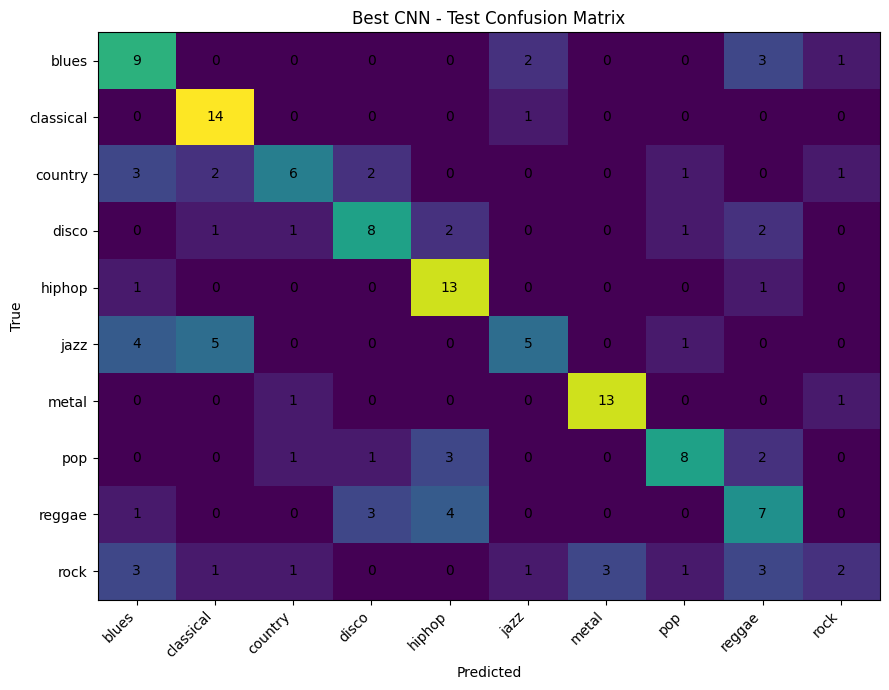

CLASSIFICATION REPORT
              precision    recall  f1-score     support
blues          0.428571  0.600000  0.500000   15.000000
classical      0.608696  0.933333  0.736842   15.000000
country        0.600000  0.400000  0.480000   15.000000
disco          0.571429  0.533333  0.551724   15.000000
hiphop         0.590909  0.866667  0.702703   15.000000
jazz           0.555556  0.333333  0.416667   15.000000
metal          0.812500  0.866667  0.838710   15.000000
pop            0.666667  0.533333  0.592593   15.000000
reggae         0.388889  0.466667  0.424242   15.000000
rock           0.400000  0.133333  0.200000   15.000000
accuracy       0.566667  0.566667  0.566667    0.566667
macro avg      0.562322  0.566667  0.544348  150.000000
weighted avg   0.562322  0.566667  0.544348  150.000000

Confusion matrix saved to:
/content/best_cnn_confusion_matrix.csv

Classification report saved to:
/content/best_cnn_classification_report.csv

Confusion matrix image saved to:
/content/best_cn

In [13]:
# ============================================================
# FINAL CLASSIFICATION REPORT + CONFUSION MATRIX
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Use the variables created by the final evaluation cell
yt = np.asarray(y_true)
yp = np.asarray(y_pred)

# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

report_dict = classification_report(
    yt,
    yp,
    labels=list(range(10)),
    target_names=GENRES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

report_df.to_csv(
    REPORT_CSV,
    index=True
)

# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    yt,
    yp,
    labels=list(range(10))
)

cm_df = pd.DataFrame(
    cm,
    index=GENRES,
    columns=GENRES
)

cm_df.to_csv(
    CONFUSION_CSV,
    index=True
)

# ------------------------------------------------------------
# DISPLAY CONFUSION MATRIX
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.imshow(
    cm,
    aspect="auto"
)

plt.title("Best CNN - Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.xticks(
    range(10),
    GENRES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    GENRES
)

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    CONFUSION_PNG,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# DISPLAY REPORT
# ------------------------------------------------------------

print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(report_df)

print("\nConfusion matrix saved to:")
print(CONFUSION_CSV)

print("\nClassification report saved to:")
print(REPORT_CSV)

print("\nConfusion matrix image saved to:")
print(CONFUSION_PNG)

print("\n✅ REPORT + CONFUSION MATRIX COMPLETE")

In [16]:
# ============================================================
# FINAL CELL - RESULTS + DOWNLOAD EVERYTHING
# ============================================================

from pathlib import Path
from google.colab import files
from sklearn.metrics import accuracy_score, f1_score
import numpy as np

# ------------------------------------------------------------
# CALCULATE FINAL METRICS DIRECTLY
# ------------------------------------------------------------

yt = np.asarray(y_true)
yp = np.asarray(y_pred)

final_accuracy = accuracy_score(yt, yp)

final_macro_f1 = f1_score(
    yt,
    yp,
    average="macro"
)

# ------------------------------------------------------------
# CHECKPOINT INFORMATION
# ------------------------------------------------------------

best_val_accuracy = None
best_epoch = None

if isinstance(ckpt, dict):

    best_val_accuracy = ckpt.get(
        "best_val_accuracy",
        None
    )

    best_epoch = ckpt.get(
        "epoch",
        None
    )


# ------------------------------------------------------------
# FINAL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL CNN RESULTS")
print("=" * 60)

print(
    f"Test Accuracy        : {final_accuracy:.4f} "
    f"({final_accuracy * 100:.2f}%)"
)

print(
    f"Test Macro-F1        : {final_macro_f1:.4f}"
)

if best_val_accuracy is not None:
    print(
        f"Best Validation Acc  : "
        f"{float(best_val_accuracy):.4f}"
    )

if best_epoch is not None:
    print(
        f"Best Epoch           : {best_epoch}"
    )

print("=" * 60)


# ------------------------------------------------------------
# CHECK ALL ARTIFACTS
# ------------------------------------------------------------

outputs = [
    CHECKPOINT,
    HISTORY_CSV,
    METRICS_CSV,
    REPORT_CSV,
    CONFUSION_CSV,
    CONFUSION_PNG
]

print("\n" + "=" * 60)
print("FINAL CNN ARTIFACT CHECK")
print("=" * 60)

all_exist = True

for output in outputs:

    path = Path(output)

    if path.exists():
        print(f"OK      : {path}")
    else:
        print(f"MISSING : {path}")
        all_exist = False


# ------------------------------------------------------------
# DOWNLOAD ALL FINAL FILES
# ------------------------------------------------------------

if all_exist:

    print("\n" + "=" * 60)
    print("DOWNLOADING FINAL CNN ARTIFACTS")
    print("=" * 60)

    for output in outputs:
        files.download(str(output))

    print("\n✅ EVERYTHING COMPLETE")
    print("✅ FINAL CNN IS DONE")
    print("✅ RESULTS AND ARTIFACTS SAVED")

else:

    print("\n⚠️ Some files are missing.")


FINAL CNN RESULTS
Test Accuracy        : 0.5667 (56.67%)
Test Macro-F1        : 0.5443
Best Validation Acc  : 0.5867
Best Epoch           : 27

FINAL CNN ARTIFACT CHECK
OK      : /content/best_cnn.pt
MISSING : /content/best_cnn_history.csv
OK      : /content/final_cnn_metrics.csv
OK      : /content/best_cnn_classification_report.csv
OK      : /content/best_cnn_confusion_matrix.csv
OK      : /content/best_cnn_confusion_matrix.png

⚠️ Some files are missing.
